# Fake News Detection — LIAR Dataset Experiment

LIAR contains short political statements (not full articles), originally labeled with 6 classes, collapsed here to binary using the strict approach.

## 1. Load LIAR Dataset

Source: Hugging Face (`liar` dataset), based on Wang (2017), "Liar, Liar Pants on Fire": A New Benchmark Dataset for Fake News Detection.


In [1]:
import pandas as pd

LIAR_COLUMNS = [
    "id", "label", "statement", "subject", "speaker", "job_title",
    "state_info", "party_affiliation", "barely_true_counts", "false_counts",
    "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "context"
]

train_raw = pd.read_csv("liar_data/train.tsv", sep="\t", header=None, names=LIAR_COLUMNS)
val_raw = pd.read_csv("liar_data/valid.tsv", sep="\t", header=None, names=LIAR_COLUMNS)
test_raw = pd.read_csv("liar_data/test.tsv", sep="\t", header=None, names=LIAR_COLUMNS)

print("Train:", train_raw.shape)
print("Validation:", val_raw.shape)
print("Test:", test_raw.shape)

train_raw.head()

Train: (10240, 14)
Validation: (1284, 14)
Test: (1267, 14)


,id,label,statement,subject,speaker,job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


## 2. Label Collapsing (6-class to Binary, Strict)

LIAR's original labels: `pants-fire`, `false`, `barely-true`, `half-true`, `mostly-true`, `true`.

Strict approach: fake = `pants-fire` + `false` only; real = `mostly-true` + `true` only. `barely-true` and `half-true` (ambiguous middle cases) are dropped entirely, giving fewer samples but cleaner, more confident labels.

In [ ]:
LABEL_MAP = {
    0: "false",
    1: "half-true",
    2: "mostly-true",
    3: "true",
    4: "barely-true",
    5: "pants-fire",
}

FAKE_LABELS = {"pants-fire", "false"}
REAL_LABELS = {"mostly-true", "true"}
# "barely-true" and "half-true" are dropped

def prepare_liar(df):
    df = df.copy()
    df["label_str"] = df["label"]
    df = df[df["label_str"].isin(FAKE_LABELS | REAL_LABELS)].copy()
    df["label"] = df["label_str"].apply(lambda x: "fake" if x in FAKE_LABELS else "real")
    df["label_id"] = df["label"].map({"real": 0, "fake": 1})
    df = df.rename(columns={"statement": "text"})
    return df[["text", "label", "label_id"]].reset_index(drop=True)

train_df = prepare_liar(train_raw)
val_df = prepare_liar(val_raw)
test_df = prepare_liar(test_raw)

print("After strict label collapsing:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nLabel distribution (train):")
print(train_df["label"].value_counts())


After strict label collapsing:
Train: (6472, 3)
Validation: (799, 3)
Test: (790, 3)

Label distribution (train):
label
real    3638
fake    2834
Name: count, dtype: int64


## 3. EDA

Word count stats (train statements):
count    6472.000000
mean       17.715853
std        10.516843
min         2.000000
25%        12.000000
50%        16.000000
75%        22.000000
max       467.000000
Name: word_count, dtype: float64


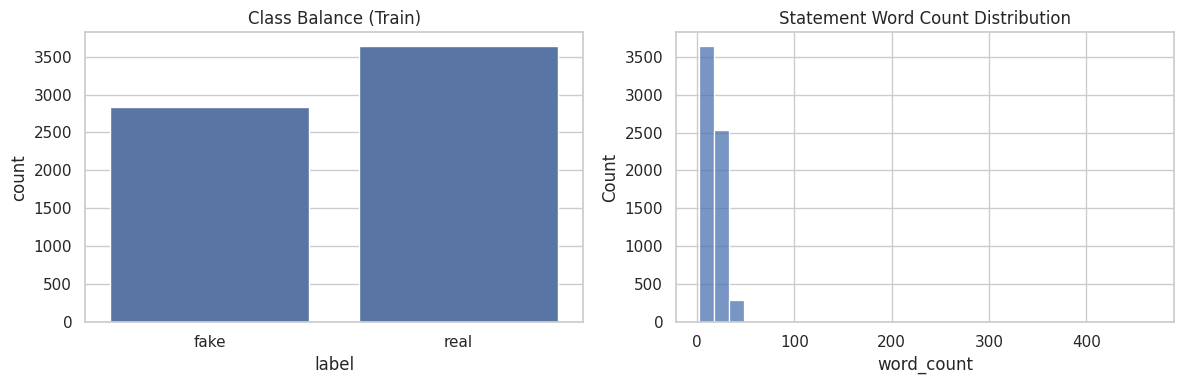

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train_df["word_count"] = train_df["text"].astype(str).apply(lambda x: len(x.split()))

print("Word count stats (train statements):")
print(train_df["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="label", data=train_df, ax=axes[0])
axes[0].set_title("Class Balance (Train)")

sns.histplot(train_df["word_count"], bins=30, ax=axes[1])
axes[1].set_title("Statement Word Count Distribution")
plt.tight_layout()
plt.show()


## 4. Splits Confirmation

LIAR ships with its own predefined train/validation/test split. Using the dataset's original splits, now filtered to binary labels.


In [4]:
print("Final split sizes after strict label collapsing:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

train_df.to_csv("liar_train.csv", index=False)
val_df.to_csv("liar_val.csv", index=False)
test_df.to_csv("liar_test.csv", index=False)
print("\nSaved: liar_train.csv, liar_val.csv, liar_test.csv")


Final split sizes after strict label collapsing:
Train: 6472
Validation: 799
Test: 790

Saved: liar_train.csv, liar_val.csv, liar_test.csv


## 5. Baseline: TF-IDF + Logistic Regression


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import time

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=2
    )),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

start = time.time()
baseline.fit(train_df["text"], train_df["label_id"])
train_time = time.time() - start

start = time.time()
val_pred = baseline.predict(val_df["text"])
infer_time = time.time() - start

val_acc = accuracy_score(val_df["label_id"], val_pred)
val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
    val_df["label_id"], val_pred, average="binary"
)

print(f"Training time: {train_time:.2f}s")
print(f"Validation inference time: {infer_time:.4f}s")
print(f"Validation Accuracy: {val_acc:.4f}")
print(classification_report(val_df["label_id"], val_pred, target_names=["real", "fake"]))

test_pred = baseline.predict(test_df["text"])
test_acc = accuracy_score(test_df["label_id"], test_pred)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(
    test_df["label_id"], test_pred, average="binary"
)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(test_df["label_id"], test_pred, target_names=["real", "fake"]))

baseline_results = {
    "model": "TF-IDF + Logistic Regression",
    "val_accuracy": val_acc,
    "val_precision": val_prec,
    "val_recall": val_rec,
    "val_f1": val_f1,
    "test_accuracy": test_acc,
    "test_precision": test_prec,
    "test_recall": test_rec,
    "test_f1": test_f1,
    "train_time_sec": train_time,
    "inference_time_sec": infer_time,
}
baseline_results


Training time: 0.34s
Validation inference time: 0.0299s
Validation Accuracy: 0.6708
              precision    recall  f1-score   support

        real       0.65      0.79      0.72       420
        fake       0.70      0.54      0.61       379

    accuracy                           0.67       799
   macro avg       0.68      0.66      0.66       799
weighted avg       0.68      0.67      0.66       799


Test Accuracy: 0.6241
              precision    recall  f1-score   support

        real       0.64      0.77      0.70       449
        fake       0.59      0.43      0.50       341

    accuracy                           0.62       790
   macro avg       0.61      0.60      0.60       790
weighted avg       0.62      0.62      0.61       790



{'model': 'TF-IDF + Logistic Regression',
 'val_accuracy': 0.6708385481852316,
 'val_precision': 0.6986301369863014,
 'val_recall': 0.5382585751978892,
 'val_f1': 0.6080476900149031,
 'test_accuracy': 0.6240506329113924,
 'test_precision': 0.5887096774193549,
 'test_recall': 0.4281524926686217,
 'test_f1': 0.49575551782682514,
 'train_time_sec': 0.34389805793762207,
 'inference_time_sec': 0.02987217903137207}

## 6. DistilBERT Fine-Tuning

In [6]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64  # LIAR statements are short (median well under 64 words)

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def to_hf_dataset(df):
    return Dataset.from_pandas(
        df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True)
    )

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

train_ds = to_hf_dataset(train_df).map(tokenize_fn, batched=True)
val_ds = to_hf_dataset(val_df).map(tokenize_fn, batched=True)
test_ds = to_hf_dataset(test_df).map(tokenize_fn, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(train_ds)


Using device: cuda


Map:   0%|          | 0/6472 [00:00<?, ? examples/s]

Map:   0%|          | 0/799 [00:00<?, ? examples/s]

Map:   0%|          | 0/790 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 6472
})


In [7]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

training_args = TrainingArguments(
    output_dir="./distilbert_liar",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

start_train = time.time()
trainer.train()
distilbert_train_time = time.time() - start_train
print(f"Training time: {distilbert_train_time:.2f}s")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.642158,0.609332,0.679599,0.711340,0.546174,0.617910
2,0.544942,0.600692,0.684606,0.648019,0.733509,0.688119
3,0.401867,0.655414,0.678348,0.682635,0.601583,0.639551
4,0.305872,0.785021,0.672090,0.690554,0.559367,0.618076


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 170.49s


In [8]:
start_infer = time.time()
test_output = trainer.predict(test_ds)
distilbert_infer_time = time.time() - start_infer

test_preds = test_output.predictions.argmax(axis=-1)
test_labels = test_output.label_ids

distilbert_test_acc = accuracy_score(test_labels, test_preds)
distilbert_test_prec, distilbert_test_rec, distilbert_test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="binary"
)

print(f"Inference time (test set): {distilbert_infer_time:.2f}s")
print(f"Test Accuracy: {distilbert_test_acc:.4f}")
print(classification_report(test_labels, test_preds, target_names=["real", "fake"]))

distilbert_results = {
    "model": "DistilBERT",
    "test_accuracy": distilbert_test_acc,
    "test_precision": distilbert_test_prec,
    "test_recall": distilbert_test_rec,
    "test_f1": distilbert_test_f1,
    "train_time_sec": distilbert_train_time,
    "inference_time_sec": distilbert_infer_time,
}

model.save_pretrained("./distilbert_liar_final")
tokenizer.save_pretrained("./distilbert_liar_final")
distilbert_results


Inference time (test set): 0.93s
Test Accuracy: 0.6886
              precision    recall  f1-score   support

        real       0.74      0.70      0.72       449
        fake       0.63      0.67      0.65       341

    accuracy                           0.69       790
   macro avg       0.68      0.69      0.68       790
weighted avg       0.69      0.69      0.69       790



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'DistilBERT',
 'test_accuracy': 0.6886075949367089,
 'test_precision': 0.631578947368421,
 'test_recall': 0.6686217008797654,
 'test_f1': 0.6495726495726496,
 'train_time_sec': 170.48600339889526,
 'inference_time_sec': 0.9264304637908936}

## 7. RoBERTa Fine-Tuning

In [9]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

ROBERTA_MODEL_NAME = "roberta-base"
roberta_tokenizer = RobertaTokenizerFast.from_pretrained(ROBERTA_MODEL_NAME)

def roberta_tokenize_fn(batch):
    return roberta_tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

roberta_train_ds = to_hf_dataset(train_df).map(roberta_tokenize_fn, batched=True)
roberta_val_ds = to_hf_dataset(val_df).map(roberta_tokenize_fn, batched=True)
roberta_test_ds = to_hf_dataset(test_df).map(roberta_tokenize_fn, batched=True)

roberta_train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
roberta_val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
roberta_test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

roberta_model = RobertaForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME, num_labels=2)
roberta_model.to(device)

roberta_training_args = TrainingArguments(
    output_dir="./roberta_liar",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none"
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_ds,
    eval_dataset=roberta_val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

start_train = time.time()
roberta_trainer.train()
roberta_train_time = time.time() - start_train
print(f"Training time: {roberta_train_time:.2f}s")


Map:   0%|          | 0/6472 [00:00<?, ? examples/s]

Map:   0%|          | 0/799 [00:00<?, ? examples/s]

Map:   0%|          | 0/790 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training time: 300.94s


In [10]:
start_infer = time.time()
roberta_test_output = roberta_trainer.predict(roberta_test_ds)
roberta_infer_time = time.time() - start_infer

roberta_test_preds = roberta_test_output.predictions.argmax(axis=-1)
roberta_test_labels = roberta_test_output.label_ids

roberta_test_acc = accuracy_score(roberta_test_labels, roberta_test_preds)
roberta_test_prec, roberta_test_rec, roberta_test_f1, _ = precision_recall_fscore_support(
    roberta_test_labels, roberta_test_preds, average="binary"
)

print(f"Inference time (test set): {roberta_infer_time:.2f}s")
print(f"Test Accuracy: {roberta_test_acc:.4f}")
print(classification_report(roberta_test_labels, roberta_test_preds, target_names=["real", "fake"]))

roberta_results = {
    "model": "RoBERTa",
    "test_accuracy": roberta_test_acc,
    "test_precision": roberta_test_prec,
    "test_recall": roberta_test_rec,
    "test_f1": roberta_test_f1,
    "train_time_sec": roberta_train_time,
    "inference_time_sec": roberta_infer_time,
}

roberta_model.save_pretrained("./roberta_liar_final")
roberta_tokenizer.save_pretrained("./roberta_liar_final")
roberta_results


Inference time (test set): 1.63s
Test Accuracy: 0.6076
              precision    recall  f1-score   support

        real       0.64      0.70      0.67       449
        fake       0.55      0.49      0.52       341

    accuracy                           0.61       790
   macro avg       0.60      0.59      0.59       790
weighted avg       0.60      0.61      0.60       790



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'model': 'RoBERTa',
 'test_accuracy': 0.6075949367088608,
 'test_precision': 0.5514950166112956,
 'test_recall': 0.4868035190615836,
 'test_f1': 0.5171339563862928,
 'train_time_sec': 300.9420518875122,
 'inference_time_sec': 1.6287429332733154}

## 8. Full Comparison — LIAR Results

In [11]:
liar_comparison = pd.DataFrame([
    {
        "model": baseline_results["model"],
        "test_accuracy": baseline_results["test_accuracy"],
        "test_precision": baseline_results["test_precision"],
        "test_recall": baseline_results["test_recall"],
        "test_f1": baseline_results["test_f1"],
        "train_time_sec": baseline_results["train_time_sec"],
        "inference_time_sec": baseline_results["inference_time_sec"],
    },
    distilbert_results,
    roberta_results,
])

liar_comparison.to_csv("liar_model_comparison.csv", index=False)
liar_comparison


,model,test_accuracy,test_precision,test_recall,test_f1,train_time_sec,inference_time_sec
0,TF-IDF + Logistic Regression,0.624051,0.588710,0.428152,0.495756,0.343898,0.029872
1,DistilBERT,0.688608,0.631579,0.668622,0.649573,170.486003,0.926430
2,RoBERTa,0.607595,0.551495,0.486804,0.517134,300.942052,1.628743
